## Phase 7 - Evaluation of Phase 6 Models

Performance evaluation of models trained in Phase 6 with metrics:
- Precision
- Recall
- F1-score
- Confusion Matrix

In [94]:
import logging
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)

In [ ]:
FEATURE_CSV_PATH = Path("feature100.csv")
SVM_MODEL_PATH = Path("svm_phase6_tuned.pkl")
DT_MODEL_PATH = Path("dt_phase6.pkl")

logging.info("Feature CSV: %s", FEATURE_CSV_PATH.resolve())
logging.info("SVM model: %s", SVM_MODEL_PATH.resolve())
logging.info("DT model: %s", DT_MODEL_PATH.resolve())

2025-12-12 23:18:45,781 [INFO] Feature CSV: E:\university\ML- fazl\SVM-and-DT\feature100.csv
2025-12-12 23:18:45,782 [INFO] SVM model: E:\university\ML- fazl\SVM-and-DT\svm_phase6_tuned.pkl
2025-12-12 23:18:45,784 [INFO] DT model: E:\university\ML- fazl\SVM-and-DT\dt_phase6.pkl


In [ ]:
logging.info("Loading features from %s", FEATURE_CSV_PATH.resolve())
df = pd.read_csv(FEATURE_CSV_PATH)

print("Data shape:", df.shape)
print(df.head())

meta_cols = ["filename", "path", "class", "label", "split"]
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f"Number of features: {len(feature_cols)}")

train_df = df[df["split"] == "train"].copy()
test_df = df[df["split"] == "test"].copy()

print(f"Number of train samples: {train_df.shape[0]}")
print(f"Number of test samples: {test_df.shape[0]}")

X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df["label"].values

X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df["label"].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

label_to_name = {}
for _, row in df.iterrows():
    label_to_name[int(row["label"])] = row["class"]

num_classes = len(set(label_to_name.keys()))
target_names = [label_to_name[i] for i in range(num_classes)]

logging.info("Number of classes: %d", num_classes)
logging.info("Class names: %s", target_names)

2025-12-12 23:18:45,794 [INFO] Loading features from E:\university\ML- fazl\SVM-and-DT\feature100.csv


Data shape: (23679, 1869)
                filename      class  label  split  aspect_ratio    mean_red  \
0  butterfly (1019).jpeg  butterfly      0  train      0.940000  163.673889   
1   butterfly (102).jpeg  butterfly      0  train      1.333333   31.376099   
2  butterfly (1020).jpeg  butterfly      0  train      1.500000   94.415405   
3  butterfly (1021).jpeg  butterfly      0  train      1.000000  214.120361   
4  butterfly (1023).jpeg  butterfly      0  train      1.639344  175.033691   

   mean_green   mean_blue     std_red  std_green  ...  hog_1754  hog_1755  \
0  172.006897  161.707520  104.156296  96.708549  ...  0.067204  0.081321   
1   31.791443   19.578003   44.298916  46.159184  ...  0.058301  0.299223   
2  118.286133   89.575745   69.398842  82.747208  ...  0.026036  0.088462   
3  182.354065  182.580139   69.926460  95.497864  ...  0.000000  0.193144   
4  181.705627  167.650269  103.348579  97.531174  ...  0.000000  0.335997   

   hog_1756  hog_1757  hog_1758  hog

2025-12-12 23:18:52,055 [INFO] Number of classes: 10
2025-12-12 23:18:52,056 [INFO] Class names: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


In [ ]:
logging.info("Loading SVM model from %s", SVM_MODEL_PATH.resolve())
svm_pipeline = joblib.load(SVM_MODEL_PATH)

logging.info("Loading Decision Tree model from %s", DT_MODEL_PATH.resolve())
dt_pipeline = joblib.load(DT_MODEL_PATH)

logging.info("Models loaded successfully")
print(f"SVM Pipeline: {svm_pipeline}")
print(f"DT Pipeline: {dt_pipeline}")

2025-12-12 23:18:52,062 [INFO] Loading SVM model from E:\university\ML- fazl\SVM-and-DT\svm_phase6_tuned.pkl
2025-12-12 23:18:52,118 [INFO] Loading Decision Tree model from E:\university\ML- fazl\SVM-and-DT\dt_phase6.pkl
2025-12-12 23:18:52,124 [INFO] Models loaded successfully


SVM Pipeline: Pipeline(steps=[('scaler', StandardScaler()),
                ('pca', PCA(n_components=0.95, random_state=42)),
                ('svm',
                 SVC(C=np.float64(84.31013932082456),
                     gamma=np.float64(0.0006290644294586153),
                     random_state=42))])
DT Pipeline: Pipeline(steps=[('scaler', StandardScaler()),
                ('pca', PCA(n_components=0.95, random_state=42)),
                ('dt',
                 DecisionTreeClassifier(max_depth=10, min_samples_leaf=4,
                                        min_samples_split=15,
                                        random_state=42))])


In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, target_names=None):
    logging.info("======================================")
    logging.info("Evaluating model: %s", model_name)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {}

    for split_name, y_true, y_pred in [
        ("train", y_train, y_train_pred),
        ("test", y_test, y_test_pred),
    ]:
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        logging.info(
            "[%s][%s] accuracy: %.4f | precision_macro: %.4f | recall_macro: %.4f | f1_macro: %.4f",
            model_name,
            split_name,
            acc,
            prec,
            rec,
            f1,
        )

        report = classification_report(
            y_true,
            y_pred,
            target_names=target_names,
            digits=4,
            zero_division=0,
        )

        print(f"\n==== {model_name} - {split_name} classification report ====\n")
        print(report)

        metrics[split_name] = {
            "accuracy": acc,
            "precision_macro": prec,
            "recall_macro": rec,
            "f1_macro": f1,
            "confusion_matrix": cm,
            "classification_report": report,
        }

    return metrics

In [ ]:
svm_metrics = evaluate_model(
    svm_pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="SVM (Phase 6 with PCA)",
    target_names=target_names,
)

2025-12-12 23:18:52,144 [INFO] ======================================
2025-12-12 23:18:52,145 [INFO] Evaluating model: SVM (Phase 6 with PCA)
2025-12-12 23:21:45,609 [INFO] [SVM (Phase 6 with PCA)][train] accuracy: 1.0000 | precision_macro: 1.0000 | recall_macro: 1.0000 | f1_macro: 1.0000
2025-12-12 23:21:45,622 [INFO] [SVM (Phase 6 with PCA)][test] accuracy: 0.6012 | precision_macro: 0.5924 | recall_macro: 0.5475 | f1_macro: 0.5614



==== SVM (Phase 6 with PCA) - train classification report ====

              precision    recall  f1-score   support

   butterfly     1.0000    1.0000    1.0000      1470
         cat     1.0000    1.0000    1.0000      1258
     chicken     1.0000    1.0000    1.0000      2022
         cow     1.0000    1.0000    1.0000      1378
         dog     1.0000    1.0000    1.0000      3683
    elephant     1.0000    1.0000    1.0000      1044
       horse     1.0000    1.0000    1.0000      1973
       sheep     1.0000    1.0000    1.0000      1248
      spider     1.0000    1.0000    1.0000      3217
    squirrel     1.0000    1.0000    1.0000      1150

    accuracy                         1.0000     18443
   macro avg     1.0000    1.0000    1.0000     18443
weighted avg     1.0000    1.0000    1.0000     18443


==== SVM (Phase 6 with PCA) - test classification report ====

              precision    recall  f1-score   support

   butterfly     0.6925    0.6351    0.6625       422
   

In [ ]:
dt_metrics = evaluate_model(
    dt_pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="DecisionTree (Phase 6 with PCA)",
    target_names=target_names,
)

2025-12-12 23:21:45,633 [INFO] ======================================
2025-12-12 23:21:45,634 [INFO] Evaluating model: DecisionTree (Phase 6 with PCA)
2025-12-12 23:21:45,974 [INFO] [DecisionTree (Phase 6 with PCA)][train] accuracy: 0.4656 | precision_macro: 0.4647 | recall_macro: 0.3837 | f1_macro: 0.3990
2025-12-12 23:21:45,992 [INFO] [DecisionTree (Phase 6 with PCA)][test] accuracy: 0.2869 | precision_macro: 0.2352 | recall_macro: 0.2274 | f1_macro: 0.2217



==== DecisionTree (Phase 6 with PCA) - train classification report ====

              precision    recall  f1-score   support

   butterfly     0.6203    0.4122    0.4953      1470
         cat     0.4539    0.2703    0.3388      1258
     chicken     0.4130    0.4565    0.4336      2022
         cow     0.3659    0.3258    0.3447      1378
         dog     0.4053    0.7043    0.5145      3683
    elephant     0.4701    0.1207    0.1921      1044
       horse     0.5003    0.4060    0.4482      1973
       sheep     0.3313    0.2580    0.2901      1248
      spider     0.6246    0.6823    0.6522      3217
    squirrel     0.4620    0.2009    0.2800      1150

    accuracy                         0.4656     18443
   macro avg     0.4647    0.3837    0.3990     18443
weighted avg     0.4743    0.4656    0.4483     18443


==== DecisionTree (Phase 6 with PCA) - test classification report ====

              precision    recall  f1-score   support

   butterfly     0.2582    0.2251    0.

In [ ]:
summary_rows = []
for model_name, m in [("SVM (Phase 6)", svm_metrics), ("DecisionTree (Phase 6)", dt_metrics)]:
    for split_name in ["train", "test"]:
        row = {
            "model": model_name,
            "split": split_name,
            "accuracy": m[split_name]["accuracy"],
            "precision_macro": m[split_name]["precision_macro"],
            "recall_macro": m[split_name]["recall_macro"],
            "f1_macro": m[split_name]["f1_macro"],
        }
        summary_rows.append(row)

metrics_df = pd.DataFrame(summary_rows)
print("\n" + "="*60)
print("Summary of Evaluation Metrics")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)

metrics_df


Summary of Evaluation Metrics
                 model split  accuracy  precision_macro  recall_macro  f1_macro
         SVM (Phase 6) train  1.000000         1.000000      1.000000  1.000000
         SVM (Phase 6)  test  0.601222         0.592434      0.547454  0.561385
DecisionTree (Phase 6) train  0.465597         0.464681      0.383701  0.398961
DecisionTree (Phase 6)  test  0.286860         0.235179      0.227408  0.221657


,model,split,accuracy,precision_macro,recall_macro,f1_macro
0,SVM (Phase 6),train,1.000000,1.000000,1.000000,1.000000
1,SVM (Phase 6),test,0.601222,0.592434,0.547454,0.561385
2,DecisionTree (Phase 6),train,0.465597,0.464681,0.383701,0.398961
3,DecisionTree (Phase 6),test,0.286860,0.235179,0.227408,0.221657


In [102]:
def plot_confusion_matrix(cm, class_labels, title):
    """
    Plot confusion matrix
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_labels,
        yticklabels=class_labels,
        cmap="Blues",
        cbar=True,
        square=True,
    )
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

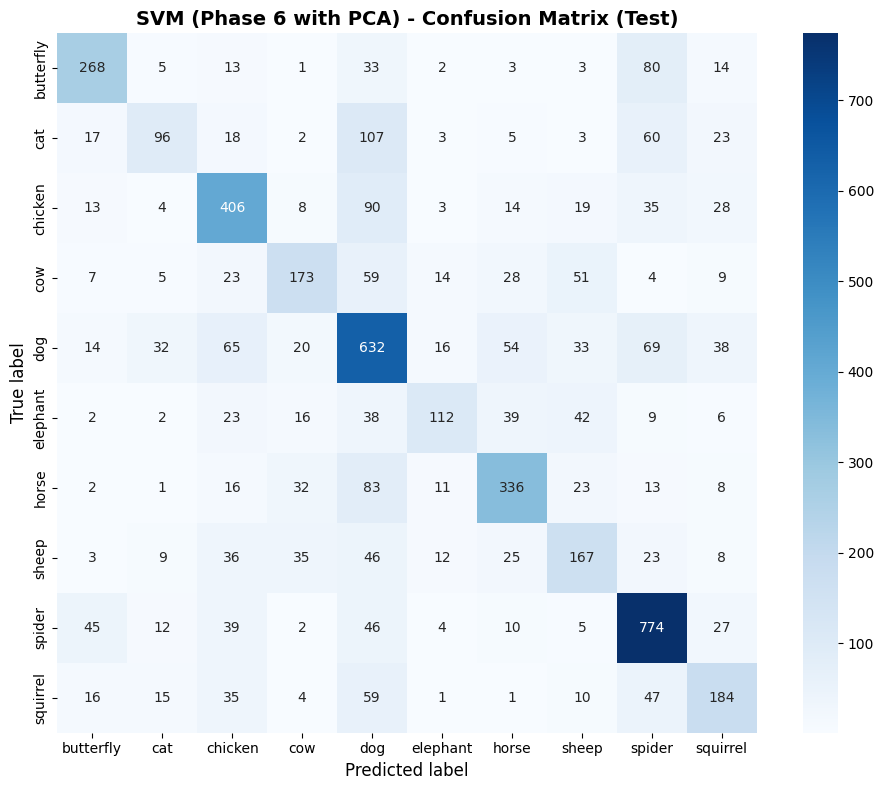

In [ ]:
cm_svm_test = svm_metrics["test"]["confusion_matrix"]
plot_confusion_matrix(
    cm_svm_test, 
    target_names, 
    "SVM (Phase 6 with PCA) - Confusion Matrix (Test)"
)

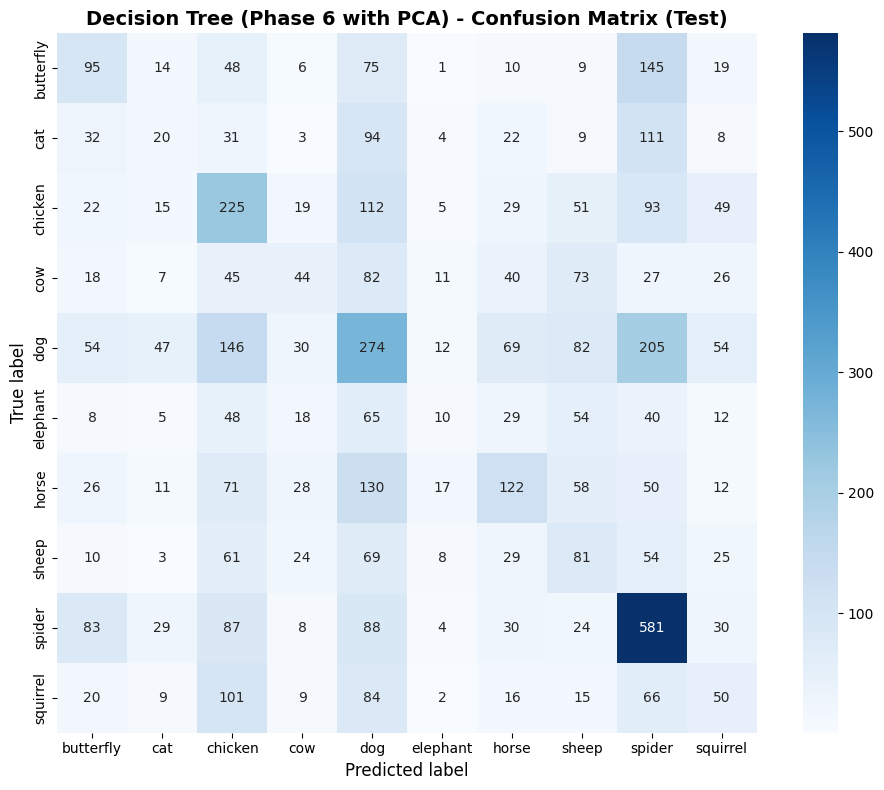

In [ ]:
cm_dt_test = dt_metrics["test"]["confusion_matrix"]
plot_confusion_matrix(
    cm_dt_test, 
    target_names, 
    "Decision Tree (Phase 6 with PCA) - Confusion Matrix (Test)"
)

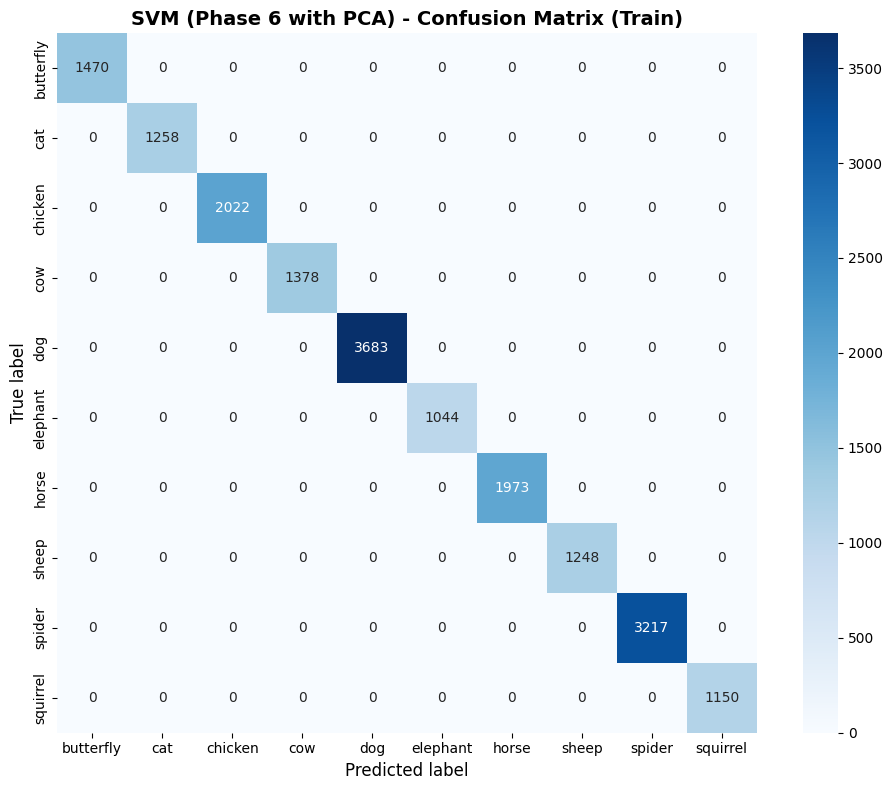

In [ ]:
cm_svm_train = svm_metrics["train"]["confusion_matrix"]
plot_confusion_matrix(
    cm_svm_train, 
    target_names, 
    "SVM (Phase 6 with PCA) - Confusion Matrix (Train)"
)

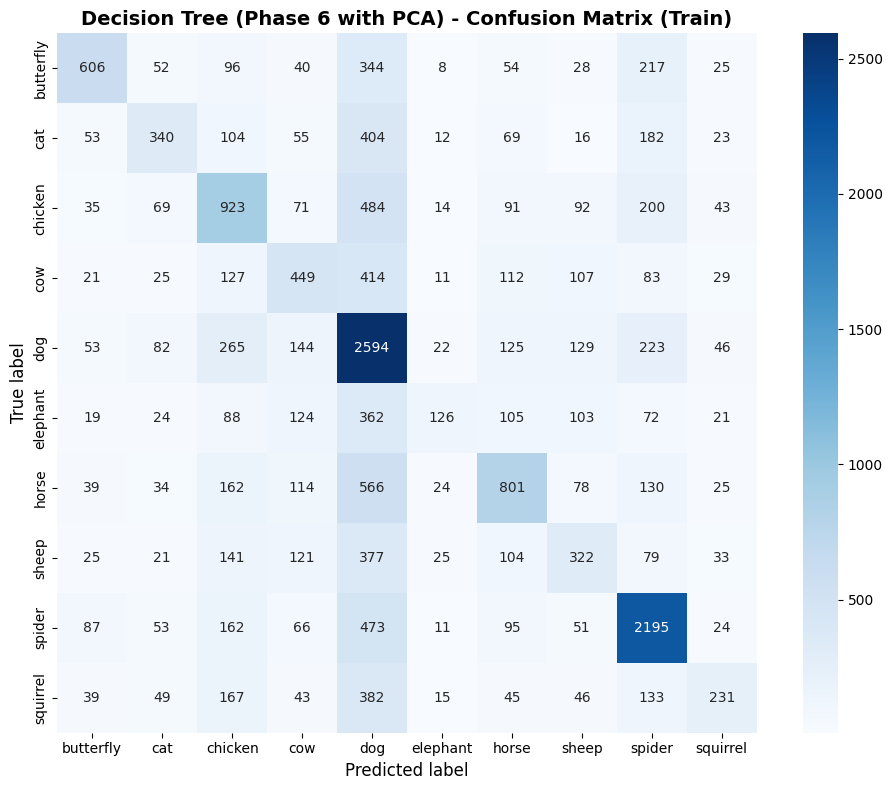

In [ ]:
cm_dt_train = dt_metrics["train"]["confusion_matrix"]
plot_confusion_matrix(
    cm_dt_train, 
    target_names, 
    "Decision Tree (Phase 6 with PCA) - Confusion Matrix (Train)"
)

C:\Users\ROG STRIX G614\AppData\Local\Temp\ipykernel_16372\1574633697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


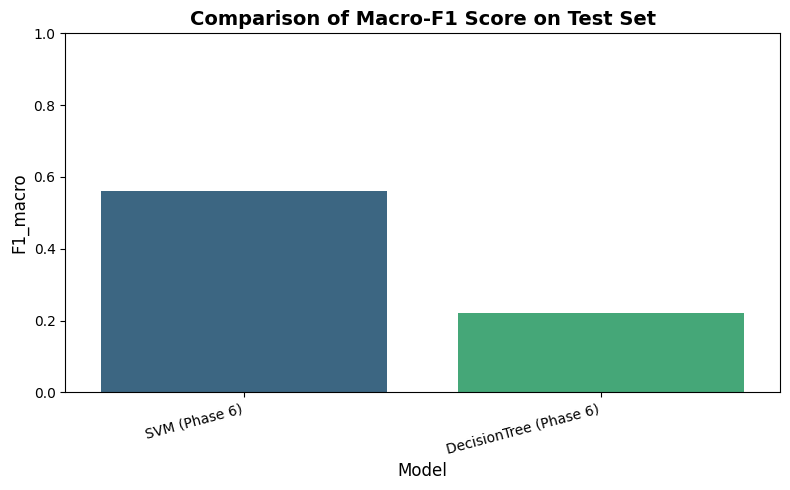

In [ ]:
test_df = metrics_df[metrics_df["split"] == "test"].copy()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=test_df,
    x="model",
    y="f1_macro",
    palette="viridis"
)
plt.title("Comparison of Macro-F1 Score on Test Set", fontsize=14, fontweight='bold')
plt.ylabel("F1_macro", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

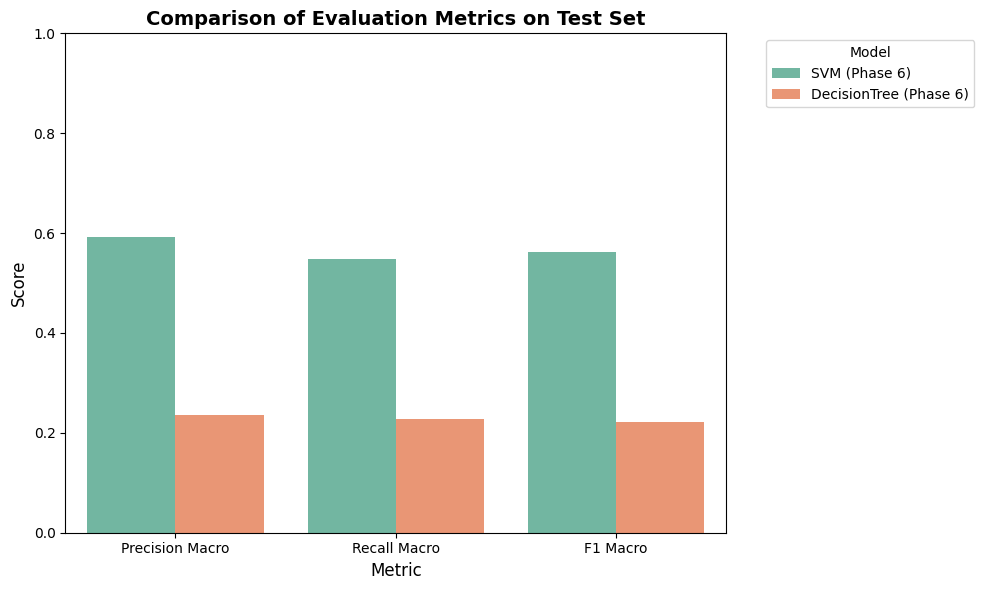

In [ ]:
test_metrics = metrics_df[metrics_df["split"] == "test"].copy()

metrics_to_plot = ["precision_macro", "recall_macro", "f1_macro"]
plot_data = []

for _, row in test_metrics.iterrows():
    for metric in metrics_to_plot:
        plot_data.append({
            "Model": row["model"],
            "Metric": metric.replace("_", " ").title(),
            "Score": row[metric]
        })

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Model",
    palette="Set2"
)
plt.title("Comparison of Evaluation Metrics on Test Set", fontsize=14, fontweight='bold')
plt.ylabel("Score", fontsize=12)
plt.xlabel("Metric", fontsize=12)
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [109]:
# Final Summary
print("\n" + "="*70)
print(" Final Summary - Phase 6 Models Evaluation ".center(70, "="))
print("="*70)

print("\n🔹 SVM (Phase 6 with PCA):")
print(f"   Test Accuracy:  {svm_metrics['test']['accuracy']:.4f}")
print(f"   Test Precision: {svm_metrics['test']['precision_macro']:.4f}")
print(f"   Test Recall:    {svm_metrics['test']['recall_macro']:.4f}")
print(f"   Test F1-Score:  {svm_metrics['test']['f1_macro']:.4f}")

print("\n🔹 Decision Tree (Phase 6 with PCA):")
print(f"   Test Accuracy:  {dt_metrics['test']['accuracy']:.4f}")
print(f"   Test Precision: {dt_metrics['test']['precision_macro']:.4f}")
print(f"   Test Recall:    {dt_metrics['test']['recall_macro']:.4f}")
print(f"   Test F1-Score:  {dt_metrics['test']['f1_macro']:.4f}")

print("\n" + "="*70)

# Determine best model
if svm_metrics['test']['f1_macro'] > dt_metrics['test']['f1_macro']:
    best_model = "SVM"
    best_f1 = svm_metrics['test']['f1_macro']
else:
    best_model = "Decision Tree"
    best_f1 = dt_metrics['test']['f1_macro']

print(f"\n🏆 Best Model: {best_model} with F1-Score = {best_f1:.4f}")
print("="*70)


============= Final Summary - Phase 6 Models Evaluation ==============

🔹 SVM (Phase 6 with PCA):
   Test Accuracy:  0.6012
   Test Precision: 0.5924
   Test Recall:    0.5475
   Test F1-Score:  0.5614

🔹 Decision Tree (Phase 6 with PCA):
   Test Accuracy:  0.2869
   Test Precision: 0.2352
   Test Recall:    0.2274
   Test F1-Score:  0.2217


🏆 Best Model: SVM with F1-Score = 0.5614
